# Robin Boundary Conditions

Tomamos la misma ecuación de poisson en el mismo intervalo:
$$\frac{d^2u}{dx^2}=2,\qquad x\in[-1,1]$$

La condición de **Dirichlet** en una frontera es:
$$u(-1)=0$$

Y la condición de **Robin** en la frontera derecha:

$$\left.\frac{du}{dx}\right|_{u=1}=u$$


La solucíon exacta es la misma:
$$u(x)=(x+1)^2$$

Estas condiciones de frontera  (Junto con la BC periódica) son tareas más críticas que aveces incluso pueden introducir inestabilidades en el entrenamiento lo que puede llebar a una solucion de la red debil.

In [4]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

dde.backend.backend_name = "pytorch"

In [5]:
import torch

In [6]:
def pde(x, y):
    dy_xx = dde.grad.hessian(y,x)
    return dy_xx -2

In [7]:
## Exact solution
def func(x):
    return (x+1)**2

### Dirichlet

In [10]:
def boundary_value1(x):
    return 0 #Sets u=0

def boundary_1(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],-1)

### Robin

In [12]:
def boundary_flux_r(x,y):
    return y #Sets du/dx=u at all x=1

def boundary_r(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],1)

### Main PINN Model

In [15]:
geom = dde.geometry.Interval(-1,1)

In [17]:
bc_1=dde.icbc.DirichletBC(geom, boundary_value1,boundary_1)
bc_r=dde.icbc.RobinBC(geom, boundary_flux_r,boundary_r)


In [18]:
## Data model:
data = dde.data.PDE(geom,
                    pde,
                    [bc_1,bc_r],
                    16,         # No of collocation points
                    2,
                    solution=func,
                    num_test=100
                   )

In [24]:
layer_size = [1] + [50]*3 + [1]
# [1]: x input layer
# [50]*3: 3 capas ocultas con 50 neuronas
# [1]: y output layer
activation = "tanh"
initializer = "Glorot uniform"

## FNN Fully conected neural network
net = dde.nn.FNN(layer_size,
                activation,
                initializer
                )

In [26]:
model = dde.Model(data,net)

model.compile("adam",lr=1e-3,metrics=["l2 relative error"])

losshistory, train_state = model.train(iterations = 1000)

Compiling model...
'compile' took 0.005896 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [4.37e+00, 1.61e+00, 7.09e-02]    [4.22e+00, 1.61e+00, 7.09e-02]    [1.32e+00]    
1000      [1.37e-04, 2.67e-07, 2.33e-10]    [1.04e-04, 2.67e-07, 2.33e-10]    [1.14e-03]    

Best model at step 1000:
  train loss: 1.37e-04
  test loss: 1.04e-04
  test metric: [1.14e-03]

'train' took 2.520472 s



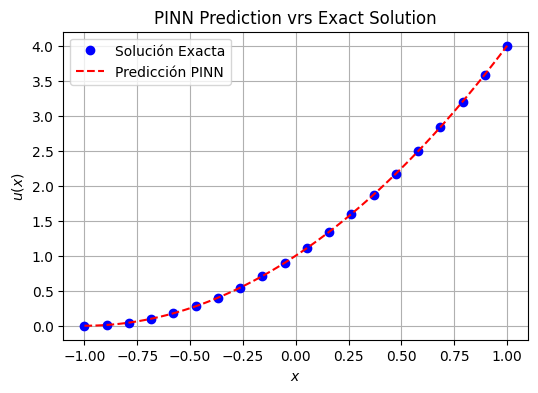

In [27]:
x_values_pinn = np.linspace(-1,1,100).reshape(-1,1)
y_pred        = model.predict(x_values_pinn)

x_values_exact = np.linspace(-1,1,20).reshape(-1,1)
y_exact        = func(x_values_exact)


plt.figure(figsize=(6,4))
plt.plot(x_values_exact,y_exact,'ob',label="Solución Exacta")

plt.plot(x_values_pinn,y_pred,'--r',label="Predicción PINN")

plt.xlabel("$x$")
plt.ylabel("$u(x)$")
plt.title("PINN Prediction vrs Exact Solution")
plt.legend()
plt.grid()
plt.show()